# Simple Model Workflow for Chest X-Ray Pneumonia

This notebook demonstrates a simple baseline end-to-end workflow for detecting pneumonia in chest X-ray images.

## (1) Dataset download


### A. KaggleHub

Use KaggleHub to fetch the Chest X-Ray Pneumonia dataset.

In [ ]:
# Install required packages (Colab)
!pip -q install kagglehub tensorflow pillow numpy --upgrade

import os
from getpass import getpass

# Configure KaggleHub auth: paste your Kaggle API token when prompted
# Your token stays in the Colab session memory; it won't be committed.
os.environ["KAGGLE_API_TOKEN"] = getpass("Paste Kaggle API token: ")
print("KAGGLE_API_TOKEN set:", "***" if os.environ.get("KAGGLE_API_TOKEN") else "MISSING")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 854.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.0.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 

In [ ]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

# Try to locate 'chest_xray' root inside the downloaded path
import os
from pathlib import Path

base = Path(path)
# Common layout in this dataset: a folder named 'chest_xray' with subfolders train/val/test
candidates = [p for p in base.rglob("chest_xray") if p.is_dir()]
if candidates:
    chest_xray_root = candidates[0]
else:
    chest_xray_root = base  # fallback

print("Using chest_xray_root:", chest_xray_root)
train_dir = chest_xray_root / "train"
val_dir = chest_xray_root / "val"
test_dir = chest_xray_root / "test"
print("train:", train_dir)
print("val:", val_dir)
print("test:", test_dir)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia
Using chest_xray_root: /kaggle/input/chest-xray-pneumonia/chest_xray
train: /kaggle/input/chest-xray-pneumonia/chest_xray/train
val: /kaggle/input/chest-xray-pneumonia/chest_xray/val
test: /kaggle/input/chest-xray-pneumonia/chest_xray/test


### B. Fallback note

If KaggleHub authentication fails, use this fallback Kaggle CLI method. Ensure your credentials are secure and not committed to source control.

In [ ]:
# 1) Create a kaggle.json with your username + key in the same cell if needed.
#    Replace <username> and <key> with your details. Do NOT commit this file.
# 2) Uncomment and run this cell only if KaggleHub errors.

# %%
# import json, os, pathlib
# pathlib.Path("/root/.kaggle").mkdir(parents=True, exist_ok=True)
# with open("/root/.kaggle/kaggle.json", "w") as f:
#     json.dump({"username": "<username>", "key": "<key>"}, f)
# os.chmod("/root/.kaggle/kaggle.json", 0o600)
# !pip -q install kaggle
# !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p data
# !unzip -q data/chest-xray-pneumonia.zip -d data
# %ls -la data


## (2) Exploratory Data Analysis (EDA)


### A. Class distribution

Inspect class distribution and visualize sample images to understand dataset characteristics and potential imbalance.

{'classes': ['NORMAL', 'PNEUMONIA'], 'train_counts': [1341, 3875]}


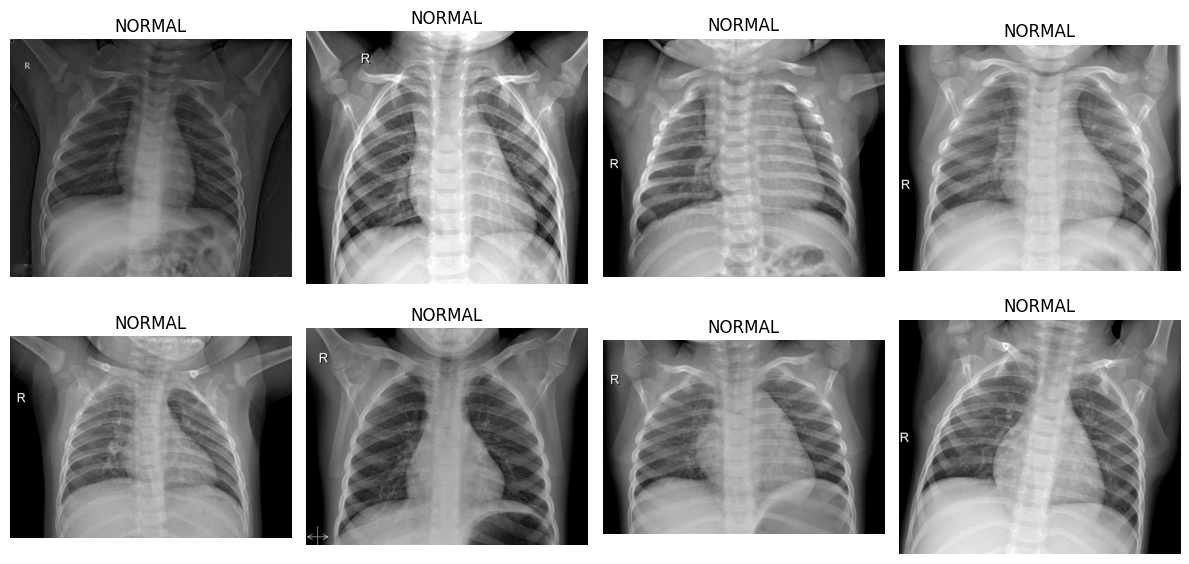

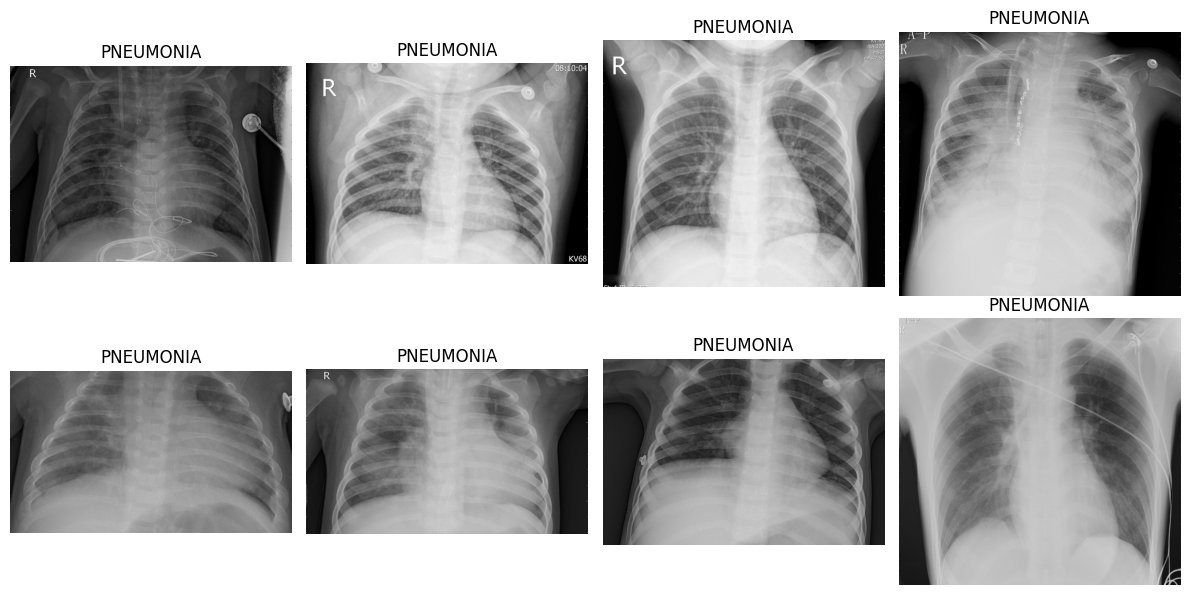

In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

classes = []
counts = []
for cls in sorted([d.name for d in Path(train_dir).iterdir() if d.is_dir()]):
    classes.append(cls)
    counts.append(len(list((Path(train_dir)/cls).glob("*.*"))))

print({"classes": classes, "train_counts": counts})

# Show grid of sample images
def show_samples(root, cls, n=8):
    files = list((Path(root)/cls).glob("*.*"))[:n]
    cols = 4
    rows = (len(files) + cols - 1) // cols
    plt.figure(figsize=(12, 3*rows))
    for i, fp in enumerate(files):
        img = tf.keras.utils.load_img(fp)
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title(cls)
    plt.tight_layout()
    plt.show()

if classes:
    show_samples(train_dir, classes[0], n=8)
    if len(classes) > 1:
        show_samples(train_dir, classes[1], n=8)

### B. Missing values

Check for missing values  or corrupted files in the dataset.

In [ ]:
import pandas as pd

def check_missing_values(directory):
    missing_counts = {}
    for cls in sorted([d.name for d in Path(directory).iterdir() if d.is_dir()]):
        cls_dir = Path(directory) / cls
        for img_file in cls_dir.glob("*.*"):
            try:
                img = tf.keras.utils.load_img(img_file)
            except Exception as e:
                missing_counts[img_file.name] = str(e)
    return missing_counts

missing_values = check_missing_values(train_dir)
if missing_values:
    print("Missing or corrupted files detected:")
    for file, error in missing_values.items():
        print(f"{file}: {error}")
else:
    print("No missing or corrupted files detected.")

No missing or corrupted files detected.


## (3) Data Preparation

Preprocessing and creating TensorFlow datasets for training, validation, and testing.


In [ ]:
# Build TensorFlow datasets
import tensorflow as tf
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(train_dir),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(val_dir),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(test_dir),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Normalize to [0,1]
def norm(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, y

train_ds = train_ds.map(norm).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(norm).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(norm).prefetch(tf.data.AUTOTUNE)


Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


## (4) Define and compile a model

Define a simple model and compile with relevant metrics and optimizer/loss parameters.



In [ ]:
# Define a simple CNN model
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## (5) Train and evaluate the model


### A. Train and evaluate the model

Train the model for a few epochs and evaluate on the test set.

In [ ]:
# Train the model
EPOCHS = 5
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print({"test_loss": float(test_loss), "test_acc": float(test_acc)})

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 557s 3s/step - accuracy: 0.8093 - loss: 0.5227 - val_accuracy: 0.7500 - val_loss: 0.4150
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 558s 3s/step - accuracy: 0.9490 - loss: 0.1382 - val_accuracy: 0.9375 - val_loss: 0.2328
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 566s 3s/step - accuracy: 0.9615 - loss: 0.1073 - val_accuracy: 0.9375 - val_loss: 0.1586
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 565s 3s/step - accuracy: 0.9749 - loss: 0.0710 - val_accuracy: 0.8750 - val_loss: 0.2428
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 561s 3s/step - accuracy: 0.9755 - loss: 0.0664 - val_accuracy: 0.8750 - val_loss: 0.2195
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7272 - loss: 1.4202
{'test_loss': 1.5631732940673828, 'test_acc': 0.7211538553237915}


### B. Plot accuracy and loss

Plot the training accuracy and loss from the history object.

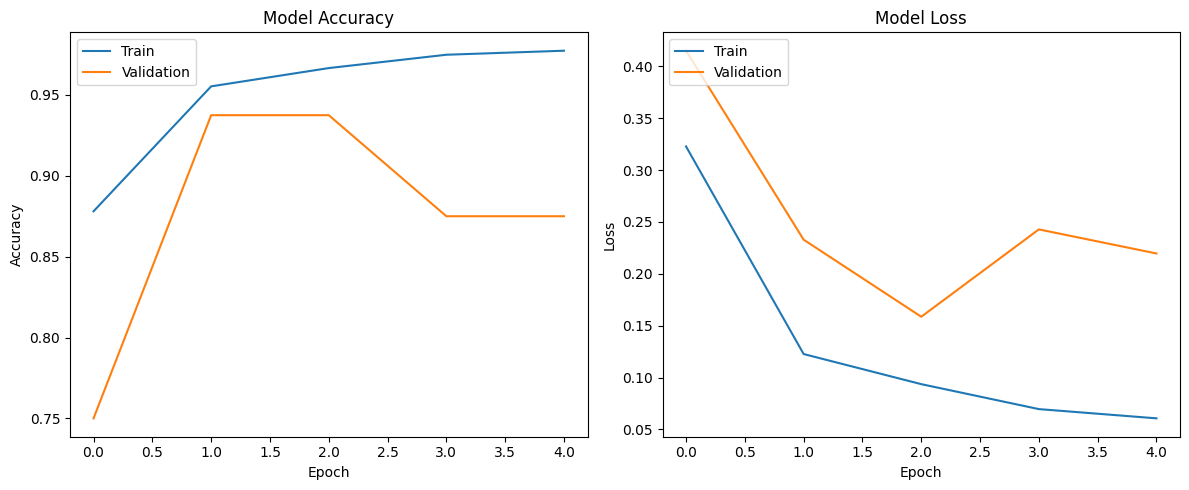

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Use the history object directly from the kernel
history_df = pd.DataFrame(history.history)

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_df['accuracy'])
plt.plot(history_df['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_df['loss'])
plt.plot(history_df['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

## (6) Model inference

Using the trained model to predict the class of new X-ray images.


In [ ]:
import tensorflow as tf
import numpy as np
from PIL import Image

# Load the saved model
loaded_model = tf.keras.models.load_model('pneumonia_model.h5')
print("Model loaded successfully!")

# Get a sample image path for inference
# Let's pick a random image from the test set for demonstration
import random
import os

# Assuming test_dir is defined from earlier cells
if 'test_dir' not in locals():
    print("Error: test_dir is not defined. Please run the data preparation cells first.")
else:
    pneumonia_images = list((test_dir / 'PNEUMONIA').glob('*.*'))
    normal_images = list((test_dir / 'NORMAL').glob('*.*'))

    if pneumonia_images and normal_images:
        # Pick one pneumonia and one normal image
        sample_image_path_pneumonia = random.choice(pneumonia_images)
        sample_image_path_normal = random.choice(normal_images)

        def preprocess_image(image_path, img_size=(224, 224)):
            img = tf.keras.utils.load_img(image_path, target_size=img_size, color_mode='rgb')
            img_array = tf.keras.utils.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)  # Create a batch
            return img_array / 255.0  # Normalize to [0,1]

        # Predict for Pneumonia image
        processed_pneumonia_img = preprocess_image(sample_image_path_pneumonia)
        prediction_pneumonia = loaded_model.predict(processed_pneumonia_img)[0][0]

        print(f"\nPrediction for {sample_image_path_pneumonia.name} (PNEUMONIA actual):")
        if prediction_pneumonia > 0.5:
            print(f"  Predicted: PNEUMONIA (Confidence: {prediction_pneumonia:.4f})")
        else:
            print(f"  Predicted: NORMAL (Confidence: {1 - prediction_pneumonia:.4f})")

        # Predict for Normal image
        processed_normal_img = preprocess_image(sample_image_path_normal)
        prediction_normal = loaded_model.predict(processed_normal_img)[0][0]

        print(f"\nPrediction for {sample_image_path_normal.name} (NORMAL actual):")
        if prediction_normal > 0.5:
            print(f"  Predicted: PNEUMONIA (Confidence: {prediction_normal:.4f})")
        else:
            print(f"  Predicted: NORMAL (Confidence: {1 - prediction_normal:.4f})")
    else:
        print("Could not find enough sample images in test_dir for inference demonstration.")

Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step

Prediction for person38_virus_83.jpeg (PNEUMONIA actual):
  Predicted: PNEUMONIA (Confidence: 1.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

Prediction for IM-0030-0001.jpeg (NORMAL actual):
  Predicted: NORMAL (Confidence: 0.7364)


## (7) Save model artifacts

Save the model and training history.

In [ ]:
# Save the model (Colab)
model.save("pneumonia_model.h5")
print("Saved: pneumonia_model.h5")

# If running in Colab, download the file
try:
    from google.colab import files
    files.download("pneumonia_model.h5")
except Exception:
    pass


Saved: pneumonia_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# Convert the history object to a pandas DataFrame and save it
history_df = pd.DataFrame(history.history)
history_df.to_csv('training_history.csv', index=False)

print("Saved training history to training_history.csv")

# Display the first few rows of the history DataFrame
display(history_df.head())

# You can also download the history file
try:
    from google.colab import files
    files.download('training_history.csv')
except Exception:
    pass

Saved training history to training_history.csv


,accuracy,loss,val_accuracy,val_loss
0,0.878067,0.322698,0.7500,0.414974
1,0.955330,0.122613,0.9375,0.232826
2,0.966641,0.093601,0.9375,0.158580
3,0.974885,0.069545,0.8750,0.242752
4,0.977377,0.060645,0.8750,0.219541


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>